In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pickle
from pathlib import Path
import numpy as np
from scipy.interpolate import make_interp_spline

### fig 3.1c

In [4]:
data_dir = Path("../data")
unmax_files = sorted(data_dir.glob("*_unmax.pkl"))
unmax_files

[PosixPath('../data/resnet18_mrl_epochs01_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs02_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs03_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs05_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs07_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs09_unmax.pkl')]

In [ ]:
unmax_lists = {}

for f in unmax_files:
    with open(f, "rb") as fh:
        obj = pickle.load(fh)
    unmax_lists[f.stem] = obj

In [6]:
unmax_lists

{'resnet18_mrl_epochs01_unmax': [23, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs02_unmax': [28, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs03_unmax': [26, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs05_unmax': [17, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs07_unmax': [19, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs09_unmax': [9, 0, 0, 0, 0, 0, 0]}

In [14]:
x = np.array([1, 2, 3, 5, 7, 9])
y = np.array([23, 28, 26, 17, 19, 9]) # low tech way

In [15]:
x_dense = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_dense)

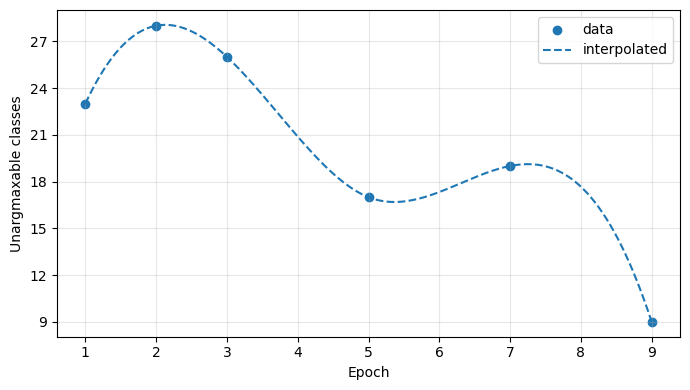

In [26]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="data")
plt.plot(x_dense, y_smooth, label="interpolated", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Unargmaxable classes")
#plt.xticks(x.astype(int))
plt.grid(True, alpha=0.3)
plt.legend()
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("../figures/unarg_vs_epoch.pdf", format="pdf")
plt.show()